In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
from Labeling_data_ingestion.data_handler.process_data import load_data
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve().parent



In [10]:
df = load_data(ROOT / "data" / "ranked" / "ranked_data.csv")

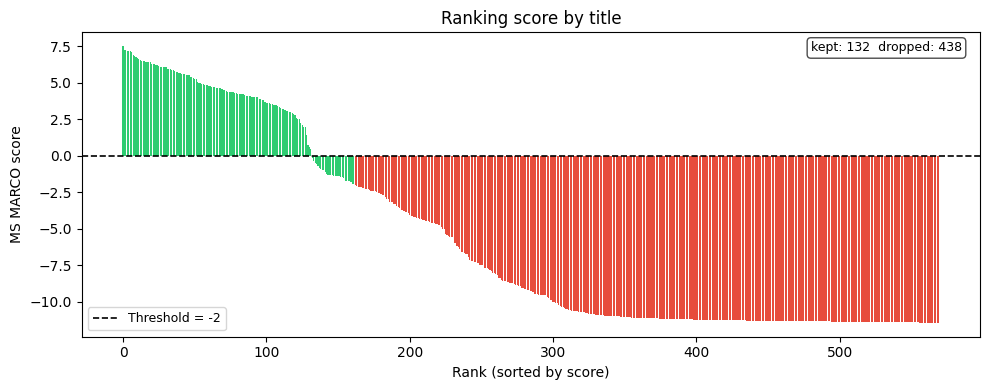

In [27]:
df = df[df["relevant"] == 1.0]
df_sorted = df.sort_values("ranking", ascending=False).reset_index(drop=True)
scores = df_sorted["ranking"].values
threshold = -2

fig, ax = plt.subplots(figsize=(10, 4))

colors = ["#2ecc71" if s >= threshold else "#e74c3c" for s in scores]
ax.bar(range(len(scores)), scores, color=colors, edgecolor="none", width=0.8)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1.2, label="Threshold = -2")
ax.set_xlabel("Rank (sorted by score)")
ax.set_ylabel("MS MARCO score")
ax.set_title("Ranking score by title")
ax.legend(fontsize=9)

kept = (scores >= 0).sum()
ax.text(0.98, 0.97, f"kept: {kept}  dropped: {len(scores)-kept}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()